# 07 — 쌍둥이 매칭: 카드 무사용 552개의 기대 카드 사용액 추정 (+ 확실 매칭 선별)

**아이디어:** 무사용 법인마다 "카드만 빼고 가장 닮은" 사용 법인 k개(쌍둥이)를 찾아, 쌍둥이들의 실제 카드 월평균(3년 총액 ÷ 35개월 — 2023.01 수집 오류 달 제외)의 중앙값을 기대치로 삼는다.

**매칭 설계(사용자 확정 2026-07-18):**
- 업종_대분류는 **정확히 일치**(같은 업종 안에서만 매칭).
- 거리 변수는 **개별 채널 4개 — 요구불 출금·요구불 입금·자동이체·인터넷뱅킹 월평균**(안 A). 총여신·총수신을 더한 6개(안 B)와 사용군 자체 검증으로 비교해 이기는 쪽 채택.
- 금액은 log1p 변환 + 표준화 후 유클리드 거리, k = 3/5/10 민감도 비교.
- 카드 관련 변수는 매칭에 절대 사용하지 않는다(무사용군은 전부 0이라 매칭이 왜곡됨).

**확실 매칭 선별(2026-07-20 추가):** 552개 전부에 기대액을 부여하던 것을, **매칭 품질이 검증된 법인만 "확실"로 분리**한다. 기준 2개(§2에서 사용군 검증으로 캘리브레이션):
1. **쌍둥이 합의도** — 10개 쌍둥이의 카드값이 서로 비슷해야(IQR÷중앙값이 사용군 중앙값 이하) 중앙값 추정이 안정적이다.
2. **매칭거리** — 사용군끼리의 거리 분포 90% 안에 들어야 한다. 이보다 멀면 "닮은 사용 법인이 존재하지 않는" 외삽이다.

**검증:** 사용군 2,819개 각각에 대해 자기 자신을 뺀 쌍둥이로 기대치를 만들어 실제와 비교(leave-one-out) — 방법의 성적표와 확실 기준의 효과를 먼저 확인한 뒤 552개에 적용한다.

**출력:** `outputs/tables/07_쌍둥이매칭_552기대액.csv`(신뢰도 컬럼 포함), `outputs/figures/07_05·07_06`

In [1]:
# ============================================================
# 0. 데이터 준비 — 법인별 (채널 4개 월평균, 카드 월평균, 업종, 그룹)
# ============================================================
import sys, os, warnings
warnings.filterwarnings('ignore')
os.environ['LOKY_MAX_CPU_COUNT'] = '4'
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.neighbors import NearestNeighbors

from common import IM, SEED, set_korean_font, load_data, save_fig, ID, YM, CARD
np.random.seed(SEED)
set_korean_font()
pd.set_option('display.width', 200)

# 36개월 완전관측(L1) 중 — 1위 왜곡 법인 제외, 카드 총액 0 = 무사용(552), 나머지 = 사용(2,819)
df = load_data()
cnt = df.groupby(ID)[YM].nunique()
d1 = df[df[ID].isin(cnt[cnt == 36].index)].copy()
tot = d1.groupby(ID)[CARD].sum().sort_values(ascending=False)
dominant = tot.index[0]
zero_ids = set(tot[tot == 0].index)
user_ids = set(tot.index) - {dominant} - zero_ids

# 법인별 월평균 프로필 (2023.02~ — 2023.01은 수집 아티팩트라 제외)
d1['총수신'] = d1[['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액']].sum(axis=1)
d1['총여신'] = d1['여신_운전자금대출잔액'] + d1['여신_시설자금대출잔액']
M = d1[d1[YM] >= 202302].groupby(ID).agg(
    카드월평균=(CARD, 'mean'),
    요구불출금=('요구불출금금액', 'mean'), 요구불입금=('요구불입금금액', 'mean'),
    자동이체=('자동이체금액', 'mean'), 인터넷뱅킹=('인터넷뱅킹거래금액', 'mean'),
    총여신=('총여신', 'mean'), 총수신=('총수신', 'mean'))
M['업종'] = d1[d1[YM] == 202512].set_index(ID)['업종_대분류']
M['그룹'] = np.select([M.index.isin(zero_ids), M.index.isin(user_ids)], ['무사용', '사용'], default='제외')
M = M[M['그룹'] != '제외']
USERS = M[M['그룹'] == '사용']
ZEROS = M[M['그룹'] == '무사용']
print(M['그룹'].value_counts().to_dict())

SET_A = ['요구불출금', '요구불입금', '자동이체', '인터넷뱅킹']
SET_B = SET_A + ['총여신', '총수신']

# 임베딩: log1p → 표준화(통계는 사용군 기준으로 적합) → 유클리드 거리용 좌표
Z = {c: (np.log1p(USERS[c]).mean(), np.log1p(USERS[c]).std()) for c in SET_B}

def embed(frame, cols):
    return np.column_stack([(np.log1p(frame[c]) - Z[c][0]) / Z[c][1] for c in cols]).astype('float64')

{'사용': 2819, '무사용': 552}


## 1. 매칭 함수와 사용군 자체 검증(leave-one-out) — 변수 세트 A vs B, k 민감도

매칭 함수는 하나다: `match_twins(targets, ...)` — targets의 각 법인에 대해 **같은 업종의 사용군**에서 쌍둥이 k개를 찾고 4개 값을 돌려준다.

| 반환 컬럼 | 의미 |
|---|---|
| 기대월액 | 쌍둥이 k개 카드 월평균의 **중앙값** |
| 보수월액 | 쌍둥이 하위 25% 값 (보수 추정용) |
| 평균거리 | 쌍둥이까지의 평균 유클리드 거리 (작을수록 닮음) |
| 합의도 | 쌍둥이 카드값의 IQR ÷ (중앙값+1) (작을수록 쌍둥이끼리 값이 비슷 = 추정 안정) |

`loo=True`면 targets가 사용군 자신이므로 첫 이웃(자기 자신, 거리 0)을 빼고 계산한다 — 검증용.
평균거리·합의도는 §2에서 "확실 매칭" 판정에 쓴다.

In [2]:
# ============================================================
# 1. 매칭 함수 + 변수세트(A/B)·k(3/5/10) 민감도 검증
# ============================================================
def match_twins(targets, cols, k, loo=False):
    """targets 각 법인에 대해 같은 업종 사용군에서 쌍둥이 k개를 찾아 기대치 계산.

    loo=True: targets가 사용군 자신 → 첫 이웃(자기 자신, 거리 0)을 제외.
    업종에 사용군이 없으면 해당 행은 NaN으로 남는다(→ '매칭불가').
    """
    out = pd.DataFrame(index=targets.index,
                       columns=['기대월액', '보수월액', '평균거리', '합의도'], dtype=float)
    for ind, tblk in targets.groupby('업종'):
        ublk = USERS[USERS['업종'] == ind]
        if len(ublk) < (2 if loo else 1):        # 쌍둥이가 하나도 없는 업종
            continue
        n_nb = min(k + 1 if loo else k, len(ublk))
        nn = NearestNeighbors(n_neighbors=n_nb).fit(embed(ublk, cols))
        dists, idx = nn.kneighbors(embed(tblk, cols))
        if loo:                                   # 첫 열 = 자기 자신 → 제거
            dists, idx = dists[:, 1:], idx[:, 1:]
        vals = ublk['카드월평균'].values
        for i, cid in enumerate(tblk.index):
            twins = vals[idx[i]]
            med = np.median(twins)
            q1, q3 = np.quantile(twins, [0.25, 0.75])
            out.loc[cid] = [med, q1, dists[i].mean(), (q3 - q1) / (med + 1)]
    return out

def loo_score(pred):
    """LOO 성적표: (순위상관, 중앙 상대오차). 상대오차는 실제 1백만원 초과분만."""
    actual = USERS['카드월평균']
    ok = pred.notna()
    rho = stats.spearmanr(actual[ok], pred[ok]).statistic
    pos = ok & (actual > 1)
    mape = (np.abs(pred[pos] - actual[pos]) / actual[pos]).median()
    return rho, mape

results = {}
for name, cols in [('A: 채널 4개', SET_A), ('B: 채널 4개+여신·수신', SET_B)]:
    for k in [3, 5, 10]:
        rho, mape = loo_score(match_twins(USERS, cols, k, loo=True)['기대월액'])
        results[(name, k)] = rho
        print(f'{name}, k={k}: 순위상관 {rho:.3f} / 중앙 상대오차 {mape:.1%}')

(best_name, BEST_K) = max(results, key=results.get)
BEST_COLS = SET_A if best_name.startswith('A') else SET_B
print(f'\n채택: {best_name}, k={BEST_K} (순위상관 최고)')

A: 채널 4개, k=3: 순위상관 0.499 / 중앙 상대오차 54.4%


A: 채널 4개, k=5: 순위상관 0.541 / 중앙 상대오차 51.1%


A: 채널 4개, k=10: 순위상관 0.578 / 중앙 상대오차 47.4%


B: 채널 4개+여신·수신, k=3: 순위상관 0.494 / 중앙 상대오차 55.0%


B: 채널 4개+여신·수신, k=5: 순위상관 0.524 / 중앙 상대오차 53.6%


B: 채널 4개+여신·수신, k=10: 순위상관 0.567 / 중앙 상대오차 47.5%

채택: A: 채널 4개, k=10 (순위상관 최고)


**해석 —** ① **채널 4개(안 A)가 여신·수신을 더한 안 B를 모든 k에서 이겼다** (k=10 기준 순위상관 0.578 vs 0.567). "카드와 함께 가는 것은 결제성 채널"이라는 2.7절의 상관 분석에 근거한 변수 선택이 검증으로 확인된 것이다 — 여신·수신은 규모 정보를 더해줄 것 같지만 실제로는 닮음을 희석시켰다. ② k는 10이 최적이다(3→5→10으로 갈수록 개선 — 쌍둥이 수가 늘며 소음이 평균화됨). ③ 성적표: **카드 정보를 전혀 쓰지 않고 실제 사용액과 순위상관 0.58, 중앙 상대오차 47%**. 즉 "누가 많이 쓸 법인인가"의 순서는 상당히 잘 맞히지만 개별 금액은 ±50% 수준의 오차가 있다 — 이 추정치는 **랭킹과 총량 산정 용도**이며 개별 법인의 확정 예측치가 아니다(사용 시 이 한계를 병기한다).

## 2. "확실 매칭" 기준 캘리브레이션 — 어떤 매칭을 믿을 수 있나

552개 전부에 기대액을 매기는 대신, **매칭 품질 신호 2개로 "확실"을 판정**한다. 임계는 임의값이 아니라 **사용군 LOO 분포에서 가져온다**:

- **합의도 ≤ 사용군 중앙값(p50)** — 쌍둥이들의 카드값이 사용군 절반 수준 이상으로 서로 비슷함. 합의도가 나쁘면 "쌍둥이는 찾았지만 그들의 카드 사용이 제각각"이라 중앙값이 불안정하다.
- **평균거리 ≤ 사용군 p90** — 사용군끼리도 흔히 나오는 거리 범위. 이걸 넘으면 채널 프로필이 사용군 분포 밖(외삽)이라 "닮은 쌍둥이"라는 전제 자체가 무너진다.

아래에서 ① 합의도가 실제로 랭킹 신뢰도를 가르는지 5분위로 확인하고, ② 확실/참고 그룹의 LOO 성적을 비교하고, ③ 검증 산점도(07_05)를 신뢰도별 색으로 그린다.

> 참고로 **개별 오차(상대오차)는 어떤 신호로도 잘 예측되지 않는다**(오차와의 순위상관 ≤0.09) — 확실 기준이 개선하는 것은 개별 금액의 정확도가 아니라 **랭킹의 신뢰도**다.

임계: 합의도 ≤ 0.73 (사용군 p50), 평균거리 ≤ 0.89 (사용군 p90)

[합의도 5분위별 LOO 성적 — 합의도가 좋을수록 랭킹이 정확]
  분위 1 (합의도 0.12~0.49): n= 564, 순위상관 0.693
  분위 2 (합의도 0.49~0.65): n= 564, 순위상관 0.589
  분위 3 (합의도 0.65~0.82): n= 563, 순위상관 0.581
  분위 4 (합의도 0.82~1.09): n= 564, 순위상관 0.496
  분위 5 (합의도 1.09~5.65): n= 564, 순위상관 0.486

[신뢰도별 LOO 성적]
  확실: n=1,312, 순위상관 0.634, 중앙 상대오차 46%
  참고: n=1,507, 순위상관 0.523, 중앙 상대오차 49%


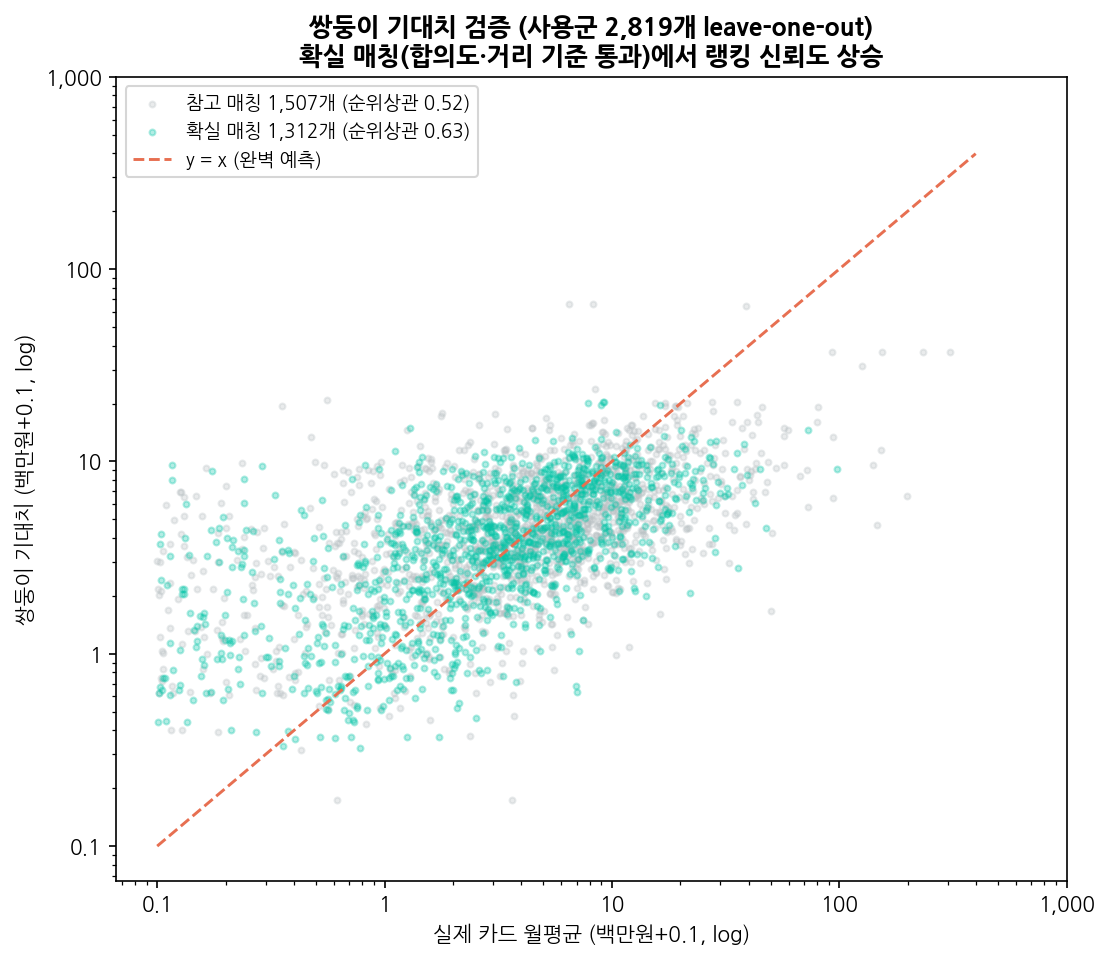

In [3]:
# ============================================================
# 2. 확실 기준: 합의도 ≤ 사용군 p50  AND  평균거리 ≤ 사용군 p90
# ============================================================
LOO = match_twins(USERS, BEST_COLS, BEST_K, loo=True)
EST = match_twins(ZEROS, BEST_COLS, BEST_K)

AGREE_THR = LOO['합의도'].median()          # 사용군 절반이 만족하는 합의 수준
DIST_THR = LOO['평균거리'].quantile(0.90)   # 사용군끼리도 이 정도 거리는 흔함 — 초과 = 외삽
print(f'임계: 합의도 ≤ {AGREE_THR:.2f} (사용군 p50), 평균거리 ≤ {DIST_THR:.2f} (사용군 p90)')

def grade(t):
    """신뢰도 등급: 확실 / 참고 / 매칭불가(업종에 사용군 없음)."""
    ok = (t['합의도'] <= AGREE_THR) & (t['평균거리'] <= DIST_THR)
    return np.where(t['기대월액'].isna(), '매칭불가', np.where(ok, '확실', '참고'))

LOO['신뢰도'] = grade(LOO)
EST['신뢰도'] = grade(EST)

# ① 합의도가 랭킹 신뢰도를 가르는가 — 5분위 검증
actual = USERS['카드월평균']
print('\n[합의도 5분위별 LOO 성적 — 합의도가 좋을수록 랭킹이 정확]')
band = pd.qcut(LOO['합의도'], 5, labels=False)
for b in range(5):
    m = band == b
    rho = stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic
    print(f'  분위 {b+1} (합의도 {LOO.loc[m, "합의도"].min():.2f}~{LOO.loc[m, "합의도"].max():.2f}): '
          f'n={m.sum():4d}, 순위상관 {rho:.3f}')

# ② 확실 vs 참고 — LOO 성적 비교
print('\n[신뢰도별 LOO 성적]')
stats_by_grade = {}
for g in ['확실', '참고']:
    m = LOO['신뢰도'] == g
    rho = stats.spearmanr(actual[m], LOO.loc[m, '기대월액']).statistic
    pos = m & (actual > 1)
    mape = (np.abs(LOO.loc[pos, '기대월액'] - actual[pos]) / actual[pos]).median()
    stats_by_grade[g] = (m, rho, mape)
    print(f'  {g}: n={m.sum():,}, 순위상관 {rho:.3f}, 중앙 상대오차 {mape:.0%}')

# ③ 검증 산점도 — 신뢰도별 색
fig, ax = plt.subplots(figsize=(7.5, 6.5))
for g, color, z in [('참고', IM['중립'], 1), ('확실', IM['민트'], 2)]:
    m, rho, _ = stats_by_grade[g]
    ax.scatter(actual[m] + 0.1, LOO.loc[m, '기대월액'] + 0.1, s=8, alpha=0.3,
               color=color, zorder=z, label=f'{g} 매칭 {m.sum():,}개 (순위상관 {rho:.2f})')
lim = max(actual.max(), LOO['기대월액'].max()) * 1.3
ax.plot([0.1, lim], [0.1, lim], color=IM['코랄'], ls='--', lw=1.4, label='y = x (완벽 예측)')
ax.set_xscale('log'); ax.set_yscale('log')
ticks = [0.1, 1, 10, 100, 1000]
ax.set_xticks(ticks); ax.set_xticklabels(['0.1', '1', '10', '100', '1,000'])
ax.set_yticks(ticks); ax.set_yticklabels(['0.1', '1', '10', '100', '1,000'])
ax.set_xlabel('실제 카드 월평균 (백만원+0.1, log)')
ax.set_ylabel('쌍둥이 기대치 (백만원+0.1, log)')
ax.set_title('쌍둥이 기대치 검증 (사용군 2,819개 leave-one-out)\n'
             '확실 매칭(합의도·거리 기준 통과)에서 랭킹 신뢰도 상승', fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout(); save_fig(fig, '07_05_쌍둥이_검증.png'); plt.show()

**해석 —** ① 합의도는 랭킹 신뢰도를 실제로 가른다 — 합의도 최상 분위의 순위상관 0.69 vs 최하 분위 0.49. ② 확실 기준(합의도 p50 & 거리 p90) 통과 그룹은 **순위상관 0.634로 전체(0.578)·참고 그룹(0.523)보다 뚜렷이 높다**. ③ 단 중앙 상대오차는 확실 46% vs 참고 49%로 큰 차이가 없다 — **확실 기준은 "개별 금액이 더 정확한 법인"이 아니라 "순서를 믿을 수 있는 법인"을 고르는 장치**다. 우선순위 리스트 용도에는 이것이 정확히 필요한 성질이다.

## 3. 552개 적용 — 확실 매칭만의 기대액 랭킹과 잠재 시장

기대액·보수치·신뢰도·매칭 품질 신호를 전부 CSV로 저장한다(참고 등급도 행은 유지 — 신뢰도 컬럼으로 구분).
**공식 인용 수치는 확실 등급의 합계**로 하고, 전체 552 합계는 상한 참고치로 병기한다.

신뢰도 분포: {'확실': 286, '참고': 266}

★ 확실 286개: 기대 월 490백만원 (연 59억원)
   보수(쌍둥이 하위 25%): 월 303백만원 (연 36억원)
   법인당 중앙값 월 0.8백만원 / 상위 30개 = 확실 합계의 41% (월 199백만원, 연 24억원)

(상한 참고) 552 전체: 월 1,367백만원 (연 164억원) — 참고 266개 몫 월 876백만원은 매칭 품질 미달로 공식 인용 제외

[확실 등급 — 업종별 기대월액 합 상위 5]
                     합계  법인수
업종                          
제조업               176.0   83
도매 및 소매업          131.0   67
건설업                73.0   32
부동산업               51.0   81
전문, 과학 및 기술 서비스업   16.0    3


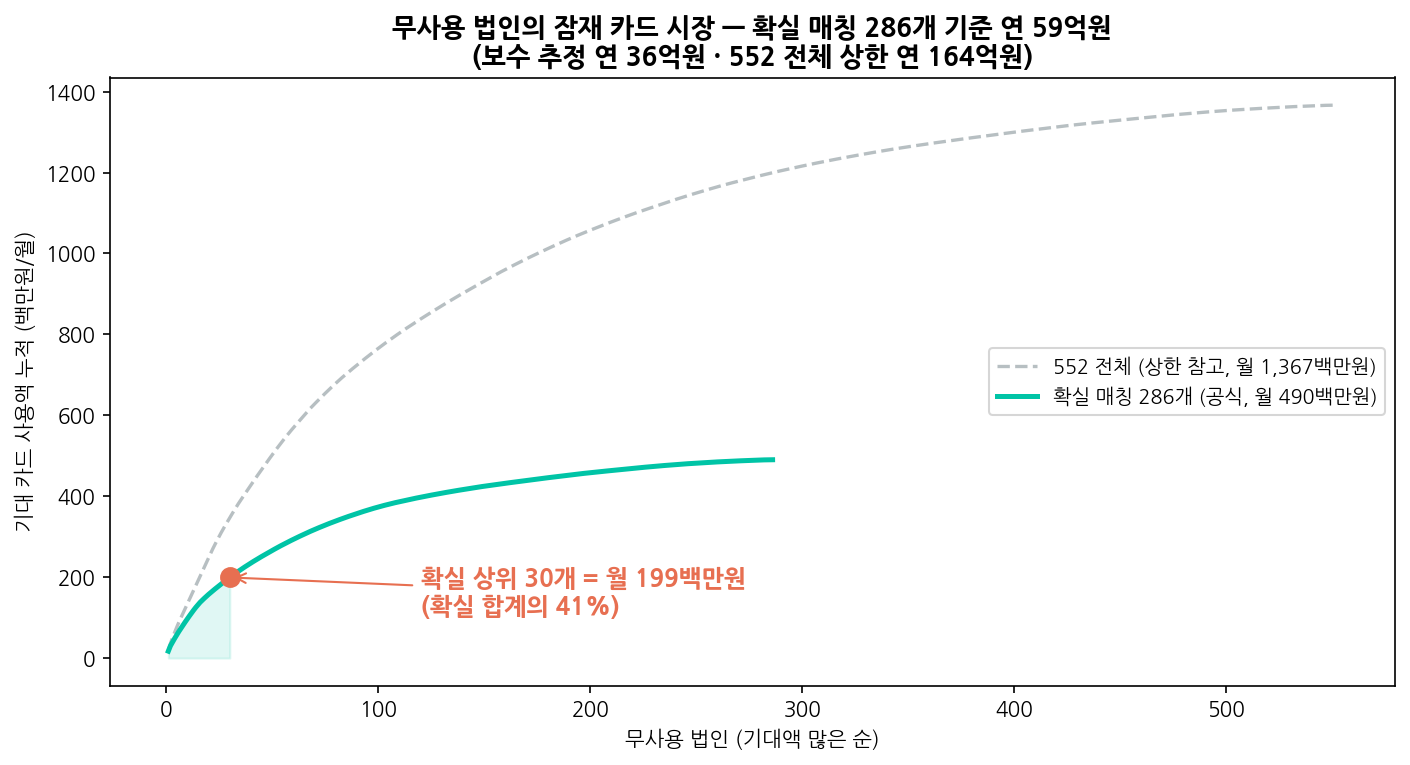

In [4]:
# ============================================================
# 3. 552 적용 — 신뢰도 등급 포함 저장 + 잠재 시장 집계
# ============================================================
est = EST.rename(columns={'보수월액': '보수월액(쌍둥이 하위25%)'}).copy()
est['업종'] = M.loc[est.index, '업종']
for c in ['요구불출금', '자동이체', '총여신']:
    est[c + '_월평균'] = M.loc[est.index, c]
# 확실 먼저, 그 안에서 기대월액 내림차순
est['_ord'] = est['신뢰도'].map({'확실': 0, '참고': 1, '매칭불가': 2})
est = est.sort_values(['_ord', '기대월액'], ascending=[True, False]).drop(columns='_ord')
est.to_csv('../outputs/tables/07_쌍둥이매칭_552기대액.csv', encoding='utf-8-sig')

conf = est[est['신뢰도'] == '확실']
ref = est[est['신뢰도'] == '참고']
tot_conf = conf['기대월액'].sum()
tot_conf_c = conf['보수월액(쌍둥이 하위25%)'].sum()
tot_all = est['기대월액'].sum()
top30 = conf['기대월액'].head(30).sum()

print(f'신뢰도 분포: {est["신뢰도"].value_counts().to_dict()}')
print(f'\n★ 확실 {len(conf)}개: 기대 월 {tot_conf:,.0f}백만원 (연 {tot_conf*12/100:,.0f}억원)')
print(f'   보수(쌍둥이 하위 25%): 월 {tot_conf_c:,.0f}백만원 (연 {tot_conf_c*12/100:,.0f}억원)')
print(f'   법인당 중앙값 월 {conf["기대월액"].median():.1f}백만원 / '
      f'상위 30개 = 확실 합계의 {top30/tot_conf:.0%} (월 {top30:,.0f}백만원, 연 {top30*12/100:,.0f}억원)')
print(f'\n(상한 참고) 552 전체: 월 {tot_all:,.0f}백만원 (연 {tot_all*12/100:,.0f}억원) — '
      f'참고 {len(ref)}개 몫 월 {ref["기대월액"].sum():,.0f}백만원은 매칭 품질 미달로 공식 인용 제외')
print('\n[확실 등급 — 업종별 기대월액 합 상위 5]')
print(conf.groupby('업종')['기대월액'].agg(합계='sum', 법인수='count')
      .sort_values('합계', ascending=False).head(5).round(0).to_string())

# 누적 곡선 — 확실(공식) vs 전체(상한 참고)
fig, ax = plt.subplots(figsize=(9.5, 5.2))
cum_all = est['기대월액'].sort_values(ascending=False).cumsum().values
ax.plot(range(1, len(cum_all) + 1), cum_all, color=IM['중립'], lw=1.6, ls='--',
        label=f'552 전체 (상한 참고, 월 {tot_all:,.0f}백만원)')
cum_c = conf['기대월액'].cumsum().values
ax.plot(range(1, len(cum_c) + 1), cum_c, color=IM['민트'], lw=2.4,
        label=f'확실 매칭 {len(conf)}개 (공식, 월 {tot_conf:,.0f}백만원)')
ax.fill_between(range(1, 31), 0, cum_c[:30], color=IM['민트'], alpha=0.12)
ax.plot([30], [cum_c[29]], 'o', ms=9, color=IM['코랄'])
ax.annotate(f'확실 상위 30개 = 월 {top30:,.0f}백만원\n(확실 합계의 {top30/tot_conf:.0%})',
            xy=(30, cum_c[29]), xytext=(120, cum_c[29] * 0.55), fontsize=11.5,
            color=IM['코랄'], fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=IM['코랄']))
ax.set_xlabel('무사용 법인 (기대액 많은 순)')
ax.set_ylabel('기대 카드 사용액 누적 (백만원/월)')
ax.set_title(f'무사용 법인의 잠재 카드 시장 — 확실 매칭 {len(conf)}개 기준 연 {tot_conf*12/100:,.0f}억원\n'
             f'(보수 추정 연 {tot_conf_c*12/100:,.0f}억원 · 552 전체 상한 연 {tot_all*12/100:,.0f}억원)',
             fontsize=12.5, fontweight='bold')
ax.legend(fontsize=9.5, loc='center right')
plt.tight_layout(); save_fig(fig, '07_06_쌍둥이_잠재곡선.png'); plt.show()

**해석 —** ① 552개 중 **확실 매칭은 286개(52%)** — 나머지 266개는 쌍둥이 합의 미달(129), 거리 초과(54), 둘 다(83)로 기대액의 근거가 약해 공식 수치에서 뺀다. ② 확실 286개의 잠재는 **월 490백만원 ≈ 연 59억원**(보수 추정 연 36억원)이고, 552 전체 상한(연 164억원)의 36%다 — 매칭을 정교화할수록 보수화되는 방향이 여기서도 유지된다. ③ 집중 구조도 유지: **확실 상위 30개가 확실 합계의 41%**(월 199백만원, 연 24억원) → 캠페인은 이 30~50개부터. ④ 업종별 확실 잠재는 제조(월 176) > 도소매(131) > 건설(73) 순. **부동산업은 확실 81개나 되지만 합계 월 51백만원** — 같은 업종 쌍둥이의 실제 사용이 낮아 "구조적 미수요" 진단이 확실 등급 안에서도 재현된다. ⑤ 참고 266개는 버리는 게 아니라 **"기대액을 못 믿는 그룹"으로 CSV에 남긴다** — 접촉 우선순위만 낮춘다.

## 4. 사례 검수 — 매칭이 진짜 "닮은꼴"인지 눈으로 확인

요약 통계(순위상관)만으로는 매칭이 실제로 그럴듯한지 알 수 없다. 판정 유형별 대표 사례 3개를 골라 **원자료를 직접 본다**:

- **① 확실 (기대액 최대):** 채널 프로필이 쌍둥이 무리 안에 들어가고, 쌍둥이들의 카드값도 모여 있어야 한다.
- **② 참고 — 쌍둥이 불합의:** 닮긴 닮았는데(거리 통과) 쌍둥이들의 카드값이 제각각 → 중앙값을 못 믿는 경우.
- **③ 참고 — 외삽:** 애초에 닮은 사용 법인이 없는 경우 → "가장 가까운 10개"조차 멀리 있음.

읽는 법: **왼쪽** = 매칭에 쓴 채널 4개에서 무사용 법인(다이아몬드)과 쌍둥이 10개(점)의 위치 — 점들이 다이아몬드 주변에 모여 있으면 닮은 것. **오른쪽** = 그 쌍둥이 10개의 실제 카드 월평균 — 점들이 모여 있으면 기대치(중앙값 선)를 믿을 수 있다.

① 확실 — 3ce55cb8959a… (도매 및 소매업) / 신뢰도=확실
          요구불출금   요구불입금   자동이체   인터넷뱅킹
무사용 법인   4768.0  4908.0  877.0  1967.0
쌍둥이 중앙값  2823.0  2836.0  672.0  2121.0
  쌍둥이 카드값: [0.1, 5.2, 10.5, 11.6, 15.2, 19.0, 19.1, 20.8, 24.4, 25.2]
  → 기대월액 17.1 / 평균거리 0.71 (임계 0.89) / 합의도 0.53 (임계 0.73)

② 참고 — 쌍둥이 불합의 — 924391af3192… (운수 및 창고업) / 신뢰도=참고
         요구불출금  요구불입금  자동이체  인터넷뱅킹
무사용 법인   715.0  719.0  95.0  643.0
쌍둥이 중앙값  572.0  571.0  77.0  531.0
  쌍둥이 카드값: [10.1, 10.7, 11.5, 12.0, 18.9, 19.3, 19.5, 45.5, 46.9, 57.3]
  → 기대월액 19.1 / 평균거리 0.62 (임계 0.89) / 합의도 1.36 (임계 0.73)

③ 참고 — 외삽(닮은꼴 없음) — 56aa96214f8c… (금융 및 보험업) / 신뢰도=참고
            요구불출금     요구불입금      자동이체  인터넷뱅킹
무사용 법인   305514.0  305486.0  264743.0   14.0
쌍둥이 중앙값    1021.0     405.0      65.0  859.0
  쌍둥이 카드값: [2.0, 5.2, 8.5, 11.4, 11.4, 14.4, 25.3, 152.0]
  → 기대월액 11.4 / 평균거리 8.69 (임계 0.89) / 합의도 0.76 (임계 0.73)



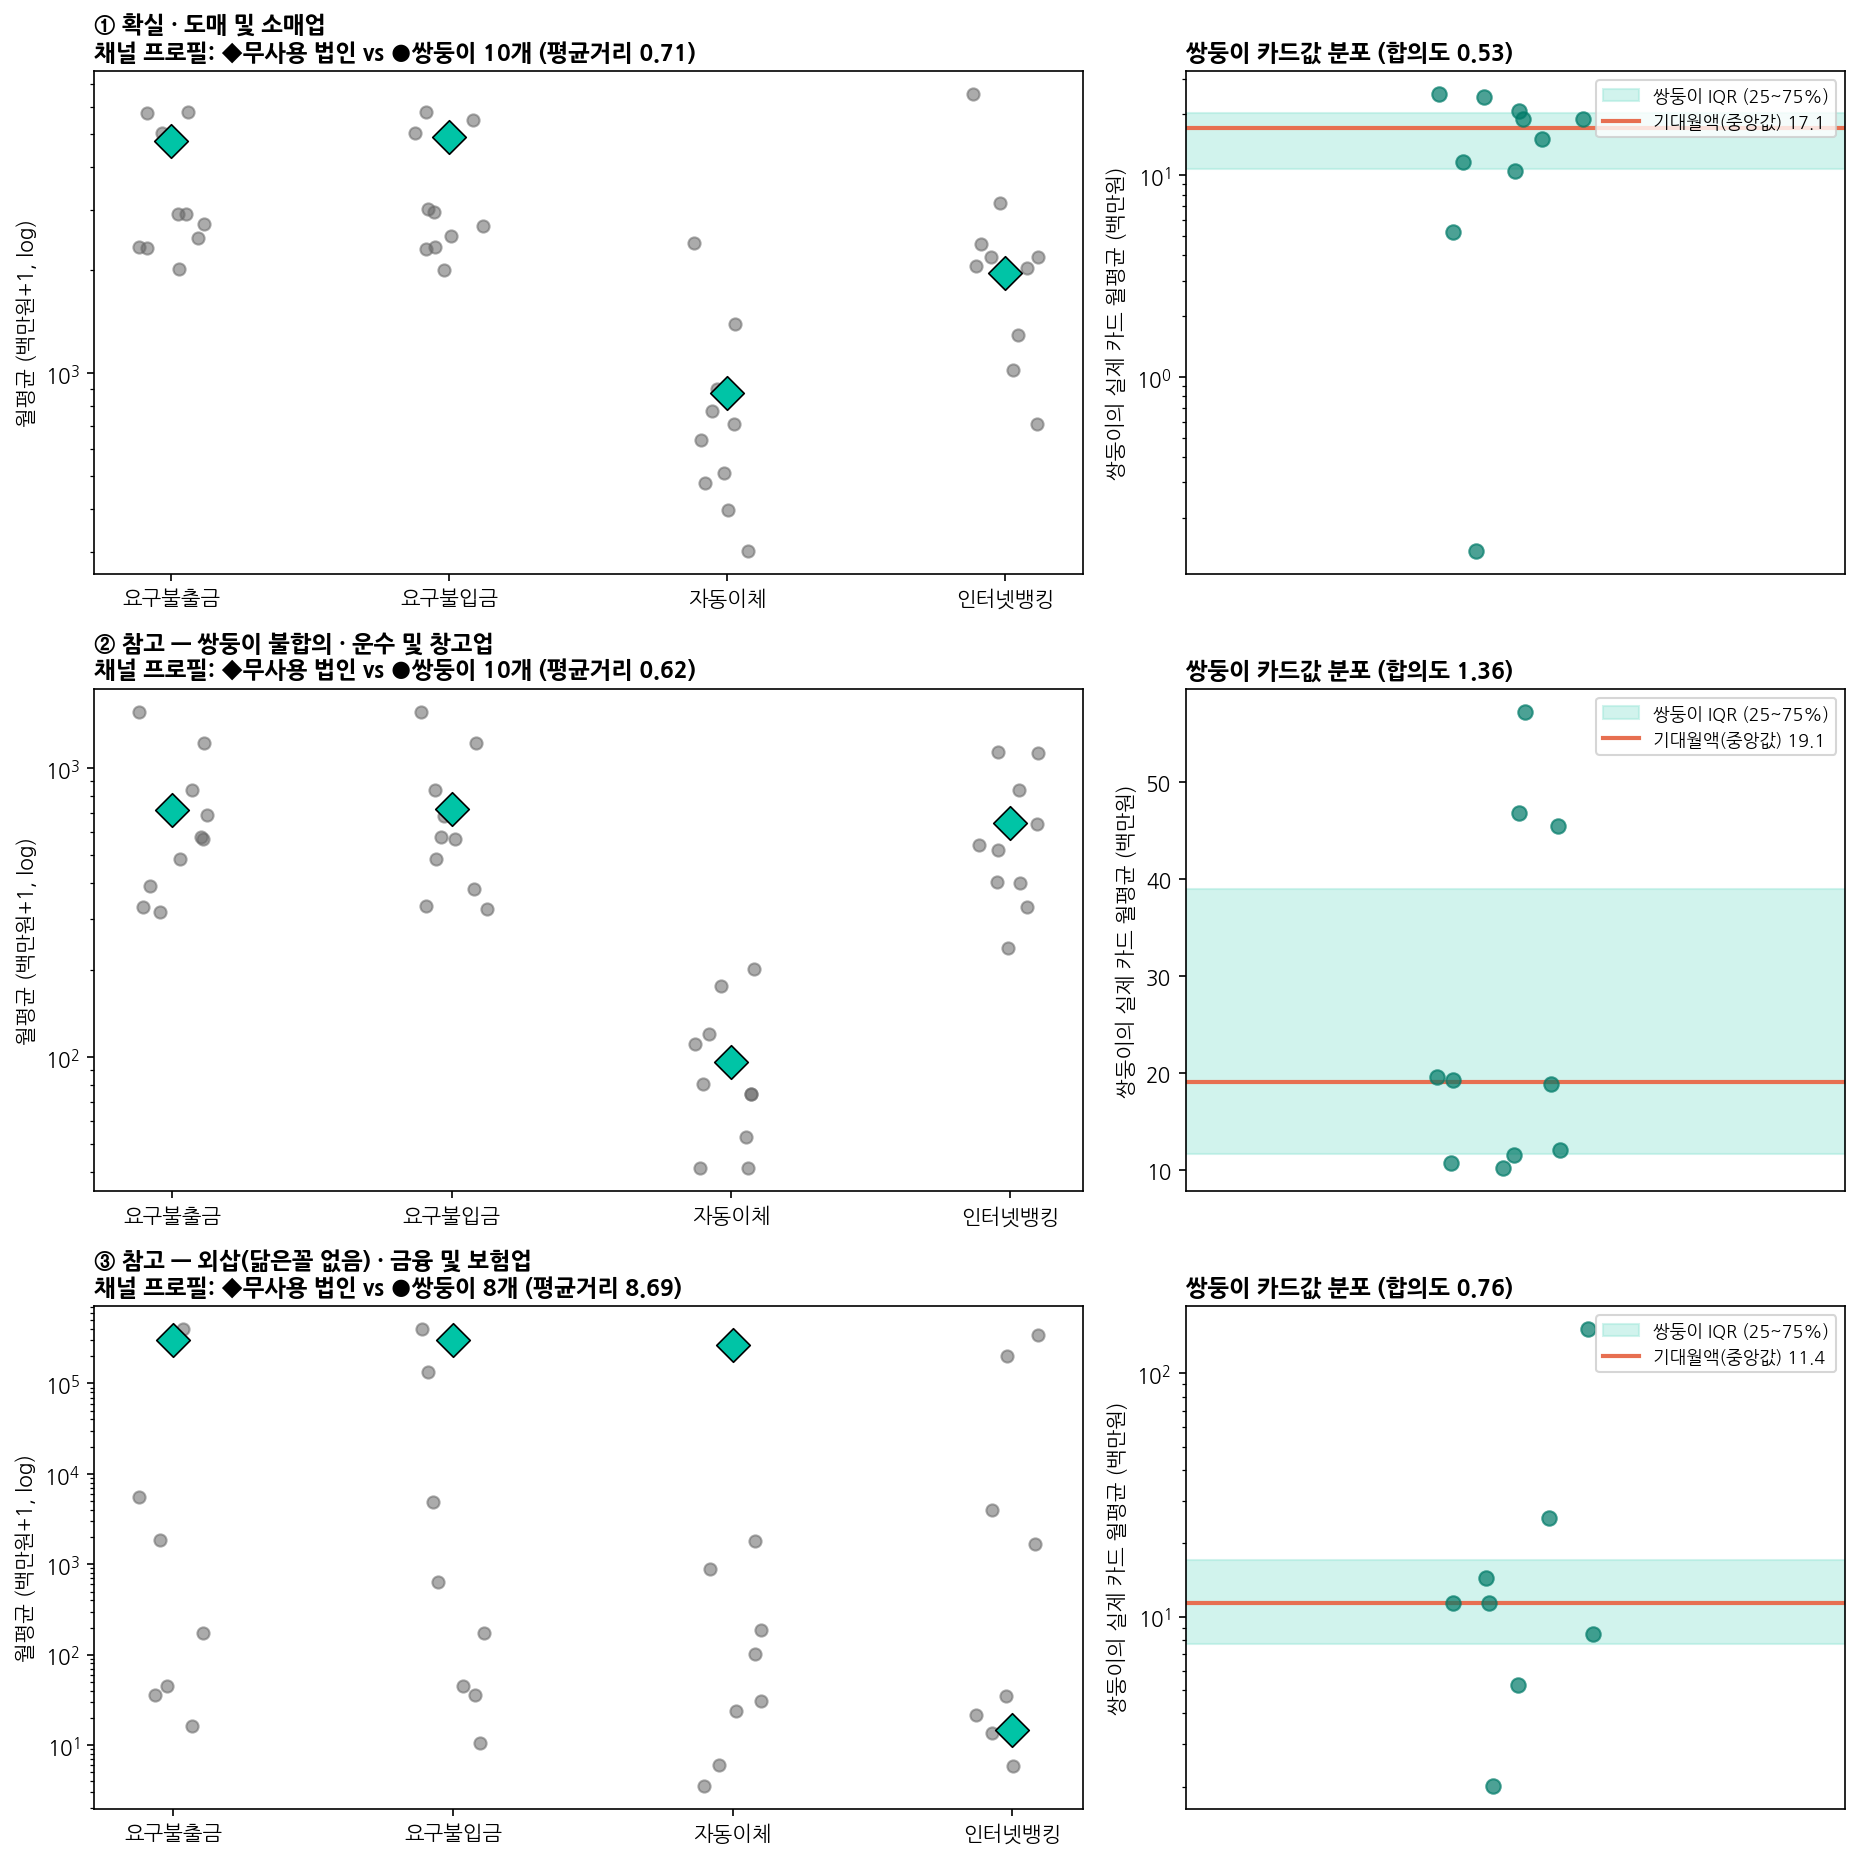

In [5]:
# ============================================================
# 4. 사례 검수 — 판정 유형별 대표 3건을 원자료로 확인
# ============================================================
def get_twins(cid):
    """법인 cid의 쌍둥이 ID·거리 반환 — match_twins()와 동일한 로직을 1건만 수행."""
    t = M.loc[[cid]]
    ublk = USERS[USERS['업종'] == t['업종'].iloc[0]]
    is_user = cid in ublk.index                    # 사용군이면 자기 자신 제외(LOO)
    n_nb = min(BEST_K + is_user, len(ublk))
    nn = NearestNeighbors(n_neighbors=n_nb).fit(embed(ublk, BEST_COLS))
    d, idx = nn.kneighbors(embed(t, BEST_COLS))
    s = 1 if is_user else 0
    return ublk.index[idx[0][s:]], d[0][s:]

# 대표 사례 선정: ① 확실 중 기대액 최대 ② 거리는 통과했지만 합의 미달 중 기대액 최대 ③ 거리 초과 중 최악
ref = EST[EST['신뢰도'] == '참고']
case_ids = [
    ('① 확실', EST[EST['신뢰도'] == '확실']['기대월액'].idxmax()),
    ('② 참고 — 쌍둥이 불합의', ref[(ref['합의도'] > AGREE_THR) & (ref['평균거리'] <= DIST_THR)]['기대월액'].idxmax()),
    ('③ 참고 — 외삽(닮은꼴 없음)', ref['평균거리'].idxmax()),
]

fig, axes = plt.subplots(3, 2, figsize=(12.5, 12.5), gridspec_kw={'width_ratios': [1.5, 1]})
for r, (label, cid) in enumerate(case_ids):
    twin_ids, dists = get_twins(cid)
    twins = M.loc[twin_ids]
    row = EST.loc[cid]

    # 왼쪽: 채널 4개 프로필 — 무사용 법인(다이아몬드) vs 쌍둥이 10개(점)
    ax = axes[r, 0]
    for j, c in enumerate(SET_A):
        ax.scatter(np.full(len(twins), j) + np.random.uniform(-0.13, 0.13, len(twins)),
                   twins[c] + 1, s=34, alpha=0.55, color=IM['그레이'], zorder=2)
        ax.scatter([j], [M.loc[cid, c] + 1], marker='D', s=130, color=IM['민트'],
                   edgecolor='black', lw=0.8, zorder=3)
    ax.set_yscale('log')
    ax.set_xticks(range(4)); ax.set_xticklabels(SET_A, fontsize=10)
    ax.set_ylabel('월평균 (백만원+1, log)')
    ax.set_title(f'{label} · {M.loc[cid, "업종"]}\n'
                 f'채널 프로필: ◆무사용 법인 vs ●쌍둥이 {len(twins)}개 (평균거리 {row["평균거리"]:.2f})',
                 fontsize=11, fontweight='bold', loc='left')

    # 오른쪽: 쌍둥이 10개의 실제 카드 월평균 — 모여 있으면 기대치를 믿을 수 있음
    ax = axes[r, 1]
    vals = twins['카드월평균'].values
    q1, q3 = np.quantile(vals, [0.25, 0.75])
    ax.axhspan(q1, q3, color=IM['연민트'], alpha=0.45, label='쌍둥이 IQR (25~75%)')
    ax.axhline(row['기대월액'], color=IM['코랄'], lw=2, label=f'기대월액(중앙값) {row["기대월액"]:.1f}')
    ax.scatter(np.random.uniform(-0.15, 0.15, len(vals)), vals, s=48, alpha=0.7,
               color=IM['딥민트'], zorder=3)
    ax.set_xlim(-0.6, 0.6); ax.set_xticks([])
    ax.set_yscale('log' if vals.max() / max(vals.min(), 0.1) > 50 else 'linear')
    ax.set_ylabel('쌍둥이의 실제 카드 월평균 (백만원)')
    ax.set_title(f'쌍둥이 카드값 분포 (합의도 {row["합의도"]:.2f})', fontsize=11, fontweight='bold', loc='left')
    ax.legend(fontsize=8.5, loc='upper right')

    # 콘솔: 숫자로도 대조
    print(f'{label} — {cid[:12]}… ({M.loc[cid, "업종"]}) / 신뢰도={row["신뢰도"]}')
    prof = pd.DataFrame({'무사용 법인': M.loc[cid, SET_A].astype(float).round(0),
                         '쌍둥이 중앙값': twins[SET_A].median().round(0)}).T
    print(prof.to_string())
    print(f'  쌍둥이 카드값: {np.sort(vals).round(1).tolist()}')
    print(f'  → 기대월액 {row["기대월액"]:.1f} / 평균거리 {row["평균거리"]:.2f}'
          f' (임계 {DIST_THR:.2f}) / 합의도 {row["합의도"]:.2f} (임계 {AGREE_THR:.2f})\n')

plt.tight_layout(); save_fig(fig, '07_07_쌍둥이_사례검수.png'); plt.show()

**해석 —** 세 사례가 판정 기준의 의미를 그대로 보여준다.

- **① 확실(도소매, 기대 17.1백만원):** 채널 4개 모두에서 다이아몬드가 쌍둥이 점무리 안에 있다(출금 4,768 vs 쌍둥이 중앙값 2,823백만원 — log 스케일에서 같은 동네). 쌍둥이 10개의 카드값도 10~25백만원에 몰려 있어(합의도 0.53) "이 법인도 월 17쯤"이라는 결론이 눈으로 납득된다.
- **② 참고 — 쌍둥이 불합의(운수·창고, 거리 0.62 통과):** 채널 프로필은 ①보다도 잘 겹친다. 그런데 쌍둥이 카드값이 **10~19백만원 무리와 45~57백만원 무리로 쪼개진다**(합의도 1.36). 중앙값 19.1은 두 무리 사이의 어중간한 값 — "닮은 법인들조차 카드 사용이 갈리는" 경우라 기대치를 공식 수치에서 뺀 근거가 명확하다.
- **③ 참고 — 외삽(금융·보험, 거리 8.69):** 무사용 법인의 출금·입금·자동이체가 **월 30만 백만원(≈3천억) 수준**인데 같은 업종 사용군은 최대 수천백만원 — 다이아몬드가 점무리에서 수십~수천 배 떨어져 있다(자금 규모가 다른 특수 법인으로 추정). 이 업종은 사용군이 8개뿐이라 "가장 가까운 이웃"조차 닮은꼴이 아니며, 여기서 나온 기대월액 11.4는 무의미하다 — 거리 임계가 걸러내는 것이 정확히 이런 케이스다.

요약: **확실 기준은 통계로만 정한 게 아니라 개별 사례 수준에서도 직관과 일치한다.** 발표에서 "왜 286개만 인용하나"를 이 그림(07_07) 한 장으로 방어할 수 있다.

## 결론 — 산출물과 사용법

- **산출물:** 552개 법인별 기대 카드 월액·보수치·**신뢰도(확실/참고)**·매칭 품질 신호(평균거리·합의도)가 담긴 `07_쌍둥이매칭_552기대액.csv`(확실 등급 우선 정렬), 검증 산점도(07_05, 신뢰도별 색), 잠재 누적 곡선(07_06, 확실 vs 전체).
- **공식 인용 수치:** 확실 매칭 286개 기준 **연 59억원(보수 36억원)**. 552 전체 연 164억원은 "매칭 품질 무시 시 상한"으로만 병기.
- **사용법:** ① **확실 등급 기대액 상위 30~50개 = 우선 공략 리스트**(확실 잠재의 41%+) ② "대출 신규·증액 후 4주 내 제안" 트리거(활성화 자연실험 근거)와 결합 ③ 기대효과는 전환율 가정별로 산정.
- **한계(병기 필수):** 확실 기준이 개선하는 것은 랭킹 신뢰도(순위상관 0.58→0.63)이며 개별 금액 오차는 여전히 ±50% 수준 — 랭킹·총량 용도로만 쓴다. 쌍둥이 기대치는 "전환 성공 시" 상한 성격으로 전환 확률을 반영하지 않으며, 카드 발급·거절 이력 등 전환 장애 요인은 데이터에 없다.